In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn umap-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 50.4 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.2 which is incompatible.


In [2]:
import pandas as pd
import numpy as np
import os
import re
import logging
from sklearn.cluster import KMeans
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm


# Setup basic logging
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
if not logger.handlers:
    stream_handler = logging.StreamHandler()
    stream_handler.setFormatter(formatter)
    logger.addHandler(stream_handler)

2025-10-29 09:07:57.530923: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761728877.752380      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761728877.815893      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 1. Load Data and Embeddings

**Note:** Please ensure `sentencePair.txt`, `sentencePair_neg.txt`, and the `artifacts` directory (containing `combined_embeddings.npy` and `combined_ids.csv`) are in the same directory as this notebook.

In [3]:
class Config:
    POS_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair.txt"
    NEG_DATA_FILE = "/kaggle/input/lrec-tcs-attack-support/sentencePair_neg.txt"
    EMB_PATH = "/kaggle/input/lrec-tcs-attack-vs-support-finetuned-embeddings/bert_finetuned_embeddings.npy"
    IDS_PATH = "/kaggle/input/lrec-tcs-attack-vs-support-finetuned-embeddings/bert_finetuned_ids.csv"
    # EMB_PATH = "/kaggle/input/lrec-tcs-support-vs-attack-embeddings/LegalBERT_cls_embeddings.npy"
    # IDS_PATH = "/kaggle/input/lrec-tcs-support-vs-attack-embeddings/LegalBERT_cls_ids.csv"

def parse_lrec_line(line: str):
    """
    Parses a single line from the .txt file.
    MUST be identical to the function in the LBERT notebook.
    """
    parts = line.strip().split("\t")
    fname_indices = [i for i, p in enumerate(parts) if p.endswith(".txt")]
    if len(fname_indices) != 2: return None
    try:
        # Use 'sentpair_id' to match the LBERT notebook's internal name
        sentpair_id = int(parts[0]) 
        sent1 = " ".join(parts[fname_indices[0] + 2 : fname_indices[1]]).strip('"')
        sent2 = " ".join(parts[fname_indices[1] + 2 : len(parts) - 2]).strip('"')
        label = parts[-1]
    except (ValueError, IndexError): return None
    return {"sentpair_id": sentpair_id, "sent1": sent1, "sent2": sent2, "label": label}

def load_full_data(config: Config):
    """
    Loads, cleans, splits, and concatenates data in the *exact* same
    order as the LBERT notebook's `load_and_split_data` followed by
    the creation of the 'combined' PairDataset.
    This ensures 1:1 row alignment with 'combined_embeddings.npy'.
    """
    logging.info("Loading full dataset with LBERT-compatible split/concat logic...")
    rows = []
    
    # --- 1. Load from both files (identical to load_and_split_data) ---
    for fp in [config.POS_DATA_FILE, config.NEG_DATA_FILE]:
        if not os.path.exists(fp):
            logging.error(f"Data file not found at '{fp}'. Please add it.")
            return None
        with open(fp, "r", encoding="utf-8") as f:
            for line in f:
                if parsed := parse_lrec_line(line):
                    # --- Use 'sentpair_id' consistently ---
                    if 'id' in parsed: # If parse_lrec_line uses 'id'
                        parsed['sentpair_id'] = parsed.pop('id')
                    rows.append(parsed)
                    
    df = pd.DataFrame(rows)
    
    # --- 2. Clean data (identical to load_and_split_data) ---
    LABEL_MAP = {"SUPPORT": 0, "ATTACK": 1, "NO_REL": 2} # Local definition
    df["label_id"] = df["label"].map(LABEL_MAP)
    # --- Use 'sentpair_id' for dropna subset ---
    df = df.dropna(subset=["sentpair_id", "sent1", "sent2", "label_id"])
    
    # --- 3. Perform the Train/Test Split (identical to load_and_split_data) ---
    # config variables
    RANDOM_STATE = 42
    TEST_SET_SIZE = 0.2
    
    train_df, test_df = train_test_split(df, test_size=TEST_SET_SIZE,
                                         random_state=RANDOM_STATE,
                                         stratify=df["label_id"])
    
    # Reset index *after* split, just like before
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    
    # --- 4. Concatenate Train and Test (identical to 'combined' PairDataset creation) ---
    df_combined_ordered = pd.concat([train_df, test_df]).reset_index(drop=True)
    
    # Ensure label_id is integer type
    df_combined_ordered['label_id'] = df_combined_ordered['label_id'].astype(int)
    
    logging.info(f"Full dataset loaded and processed like LBERT notebook. Total samples: {len(df_combined_ordered)}")
    
    # This df is now row-aligned with the embeddings
    return df_combined_ordered

# --- Load all components ---
cfg = Config()
df_aligned = load_full_data(cfg) 

if df_aligned is not None:
    embeddings = np.load(cfg.EMB_PATH)
    ids_df = pd.read_csv(cfg.IDS_PATH) # Load for verification
    
    logger.info(f"Loaded DataFrame shape: {df_aligned.shape}")
    logger.info(f"Loaded embeddings shape: {embeddings.shape}")
    logger.info(f"Loaded IDs shape: {ids_df.shape}")
    
    # --- Alignment Check ---
    if len(df_aligned) == len(embeddings) and len(df_aligned) == len(ids_df):
        logger.info("SUCCESS: DataFrame, embeddings, and IDs have matching lengths.")
        # Final check: compare the IDs column-wise
        mismatches = (df_aligned['sentpair_id'] != ids_df['id']).sum()
        if mismatches == 0:
            logger.info("✅ SUCCESS: 'sentpair_id' column matches 'id' column from CSV.")
        else:
            logger.error(f"--- CRITICAL ERROR ---")
            logger.error(f"ID mismatch detected: {mismatches} rows have different IDs.")
            logger.error("Even though lengths match, the row order is incorrect.")
            logger.error("Check data parsing/cleaning/splitting logic VERY carefully.")
            df_aligned = None # Stop execution
    else:
        logger.error("--- CRITICAL ERROR ---")
        logger.error("Shape mismatch between loaded data and embeddings.")
        logger.error(f"DataFrame rows: {len(df_aligned)}")
        logger.error(f"Embedding rows: {len(embeddings)}")
        logger.error(f"ID CSV rows: {len(ids_df)}")
        logger.error("This means the data loading logic is out of sync with the embedding generation notebook.")
        df_aligned = None # Stop subsequent cells
else:
    logger.error("Could not load data. Halting notebook execution.")


2025-10-29 09:08:22,060 - INFO - Loaded DataFrame shape: (40506, 5)
2025-10-29 09:08:22,061 - INFO - Loaded embeddings shape: (40506, 768)
2025-10-29 09:08:22,063 - INFO - Loaded IDs shape: (40506, 1)
2025-10-29 09:08:22,064 - INFO - SUCCESS: DataFrame, embeddings, and IDs have matching lengths.
2025-10-29 09:08:22,066 - INFO - ✅ SUCCESS: 'sentpair_id' column matches 'id' column from CSV.


## 2. Elbow Method for Optimal K (Knee Plot)

Calculate the Sum of Squared Distances (Inertia) for different `k` values. The 'elbow' or 'knee' suggests a good trade-off.

2025-10-29 09:08:22,077 - INFO - Calculating SSE for k in range(1, 11)...


  0%|          | 0/10 [00:00<?, ?it/s]

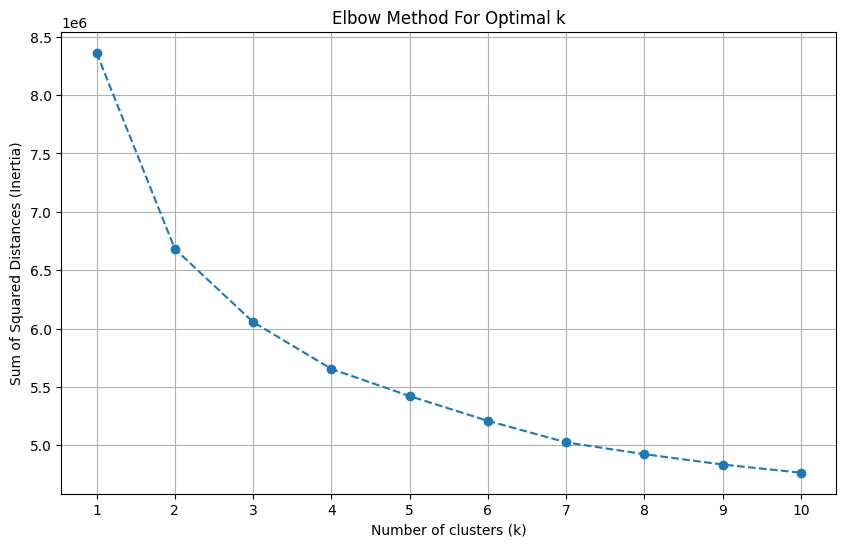

2025-10-29 09:10:09,131 - INFO - Examine the plot. The 'elbow' point indicates a potential optimal k.
2025-10-29 09:10:09,132 - INFO - Consider k=2 (Arg vs Non-Arg) or k=3 (Attack/Support/NoRel).


In [4]:
if embeddings is not None:
    sse = {}
    k_range = range(1, 11) # Test k from 1 to 10
    logger.info(f"Calculating SSE for k in {k_range}...")

    for k_val in tqdm(k_range):
        kmeans_elbow = KMeans(n_clusters=k_val, random_state=42, n_init=10)
        kmeans_elbow.fit(embeddings)
        sse[k_val] = kmeans_elbow.inertia_ # SSE

    # Plotting the Elbow Curve
    plt.figure(figsize=(10, 6))
    plt.plot(list(sse.keys()), list(sse.values()), marker='o', linestyle='--')
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Sum of Squared Distances (Inertia)")
    plt.title("Elbow Method For Optimal k")
    plt.xticks(list(sse.keys()))
    plt.grid(True)
    plt.show()

    logger.info("Examine the plot. The 'elbow' point indicates a potential optimal k.")
    logger.info("Consider k=2 (Arg vs Non-Arg) or k=3 (Attack/Support/NoRel).")
else:
     logger.error("Cannot run Elbow method because embeddings are not loaded.")

## 3. K-Means Clustering

Choose `n_clusters` based on the elbow plot or your hypothesis.

In [5]:
if df_aligned is not None and embeddings is not None:
    # --- SET YOUR DESIRED NUMBER OF CLUSTERS HERE ---
    n_clusters = 2 # Defaulting to 2, ADJUST AS NEEDED based on Elbow plot
    # -------------------------------------------------

    logger.info(f"Running K-Means with n_clusters={n_clusters}...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Add cluster labels to the aligned DataFrame
    df_aligned['cluster'] = cluster_labels

    # Calculate Silhouette Score (only if more than 1 cluster)
    if n_clusters > 1:
        try:
            silhouette_avg = silhouette_score(embeddings, cluster_labels)
            logger.info(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.4f}")
        except Exception as e:
            logger.warning(f"Could not calculate silhouette score: {e}")
    else:
        logger.info("Silhouette score requires n_clusters > 1.")

else:
    logger.error("Cannot run K-Means because data or embeddings are not loaded.")

2025-10-29 09:10:09,141 - INFO - Running K-Means with n_clusters=2...
2025-10-29 09:11:05,901 - INFO - For n_clusters = 2, the average silhouette_score is : 0.1841


## 4. Analysis: Cluster Composition

2025-10-29 09:11:05,909 - INFO - --- Cluster Composition Analysis ---


\nCross-tabulation (Original Label vs. Predicted Cluster):
cluster     0      1
label               
ATTACK   8901    859
NO_REL   3772  16228
SUPPORT  9847    899


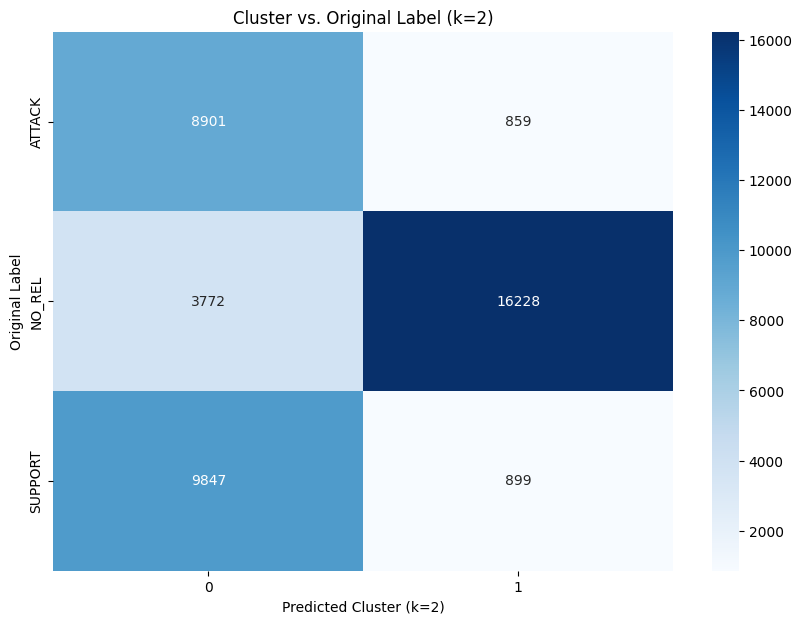

In [6]:
if df_aligned is not None:
    if 'cluster' in df_aligned.columns:
        logger.info("--- Cluster Composition Analysis ---")

        crosstab = pd.crosstab(df_aligned['label'], df_aligned['cluster'])
        print("\\nCross-tabulation (Original Label vs. Predicted Cluster):")
        print(crosstab)

        plt.figure(figsize=(10, 7)) # Adjusted size slightly
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
        # Use the n_clusters variable in the title and xlabel
        plt.title(f"Cluster vs. Original Label (k={n_clusters})")
        plt.xlabel(f"Predicted Cluster (k={n_clusters})")
        plt.ylabel("Original Label")
        plt.show()
    else:
        logger.error("K-Means clustering step did not complete. Cannot show composition.")
else:
    logger.error("Cannot analyze composition because data is not loaded.")


# For n = 2, Precision = 18748/22520 = 0.832 (Argumentative vs Non Argumentative)
# Recall = 18748/20506 = 0.914
# F1 = 0.871
#Accuracy = 34976/40506 = 0.863

## 5. Analysis: Sample Inspection

checking few points from each cluster

In [7]:
if df_aligned is not None and 'cluster' in df_aligned.columns:
    pd.set_option('display.max_colwidth', 200)

    # Display samples for each cluster found
    unique_clusters = sorted(df_aligned['cluster'].unique())
    num_clusters_found = len(unique_clusters) # Get actual number found
    logger.info(f"Found {num_clusters_found} unique cluster labels: {unique_clusters}")


    for clus_id in unique_clusters:
        print("\\n" + "="*50)
        logger.info(f"Sample Points from Cluster {clus_id}")
        print("="*50)
        cluster_data = df_aligned[df_aligned['cluster'] == clus_id]
        sample_size = min(5, len(cluster_data)) # Sample up to 5

        if sample_size > 0:
           print(cluster_data[['sent1', 'sent2', 'label']].sample(sample_size, random_state=42))
        else:
           print(f"Cluster {clus_id} has no samples.")
else:
    logger.error("Cannot inspect samples because data or cluster labels are missing.")

2025-10-29 09:11:06,173 - INFO - Found 2 unique cluster labels: [0, 1]
2025-10-29 09:11:06,175 - INFO - Sample Points from Cluster 0
2025-10-29 09:11:06,189 - INFO - Sample Points from Cluster 1


\n==================================================
                                                                                                                                                                                                         sent1  \
29650              The Kerala High Court had specifically further observed that the UGC scheme did not become applicable as it was not obligatory for the Government and the Universities to follow the same .   
31285  At the risk of repetition , in the present case both the Land Tribunal and the High Court held that the appellants were in possession of the land in dispute and the 16 entries in the Record of Rig...   
21311                             Thus , it is evident that for awarding the death sentence , there must be existence of aggravating circumstances and the consequential absence of mitigating circumstances .   
9773   The appellant filed objection to the acceptance of the second respondent 's nomination at the time o

## 6. Visualization with UMAP

visualizing the clusters to see the separation.

2025-10-29 09:11:06,211 - INFO - Reducing dimensions with UMAP for visualization...
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
2025-10-29 09:12:11,615 - INFO - Plotting by K-Means Cluster (k=2)...


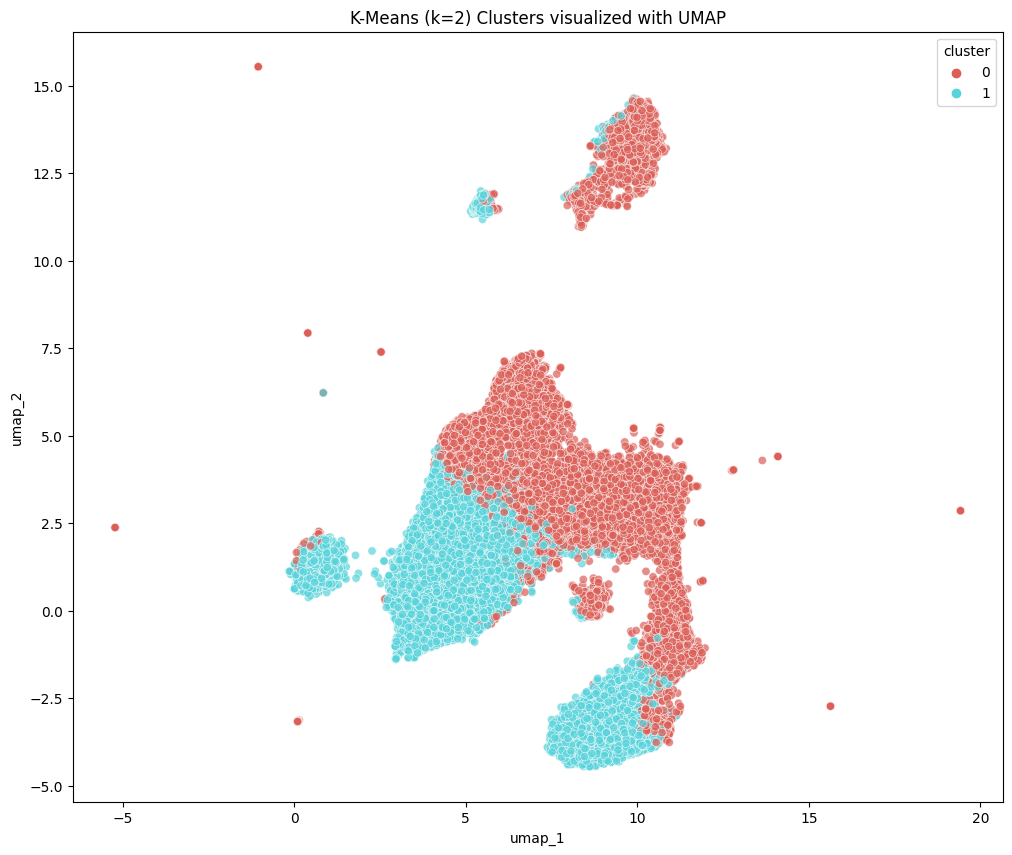

2025-10-29 09:12:13,006 - INFO - Plotting by Original Label...


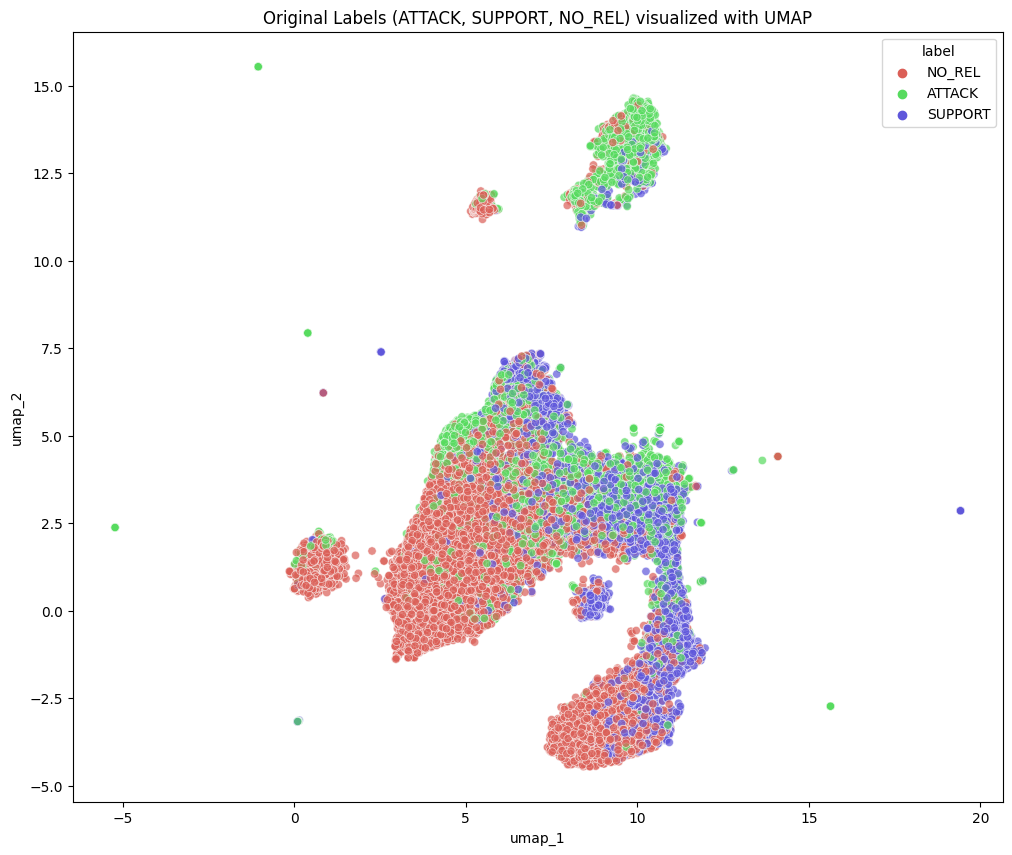

2025-10-29 09:12:14,373 - INFO - Plotting UMAP with Color=Cluster (k=2), Shape=Original Label...


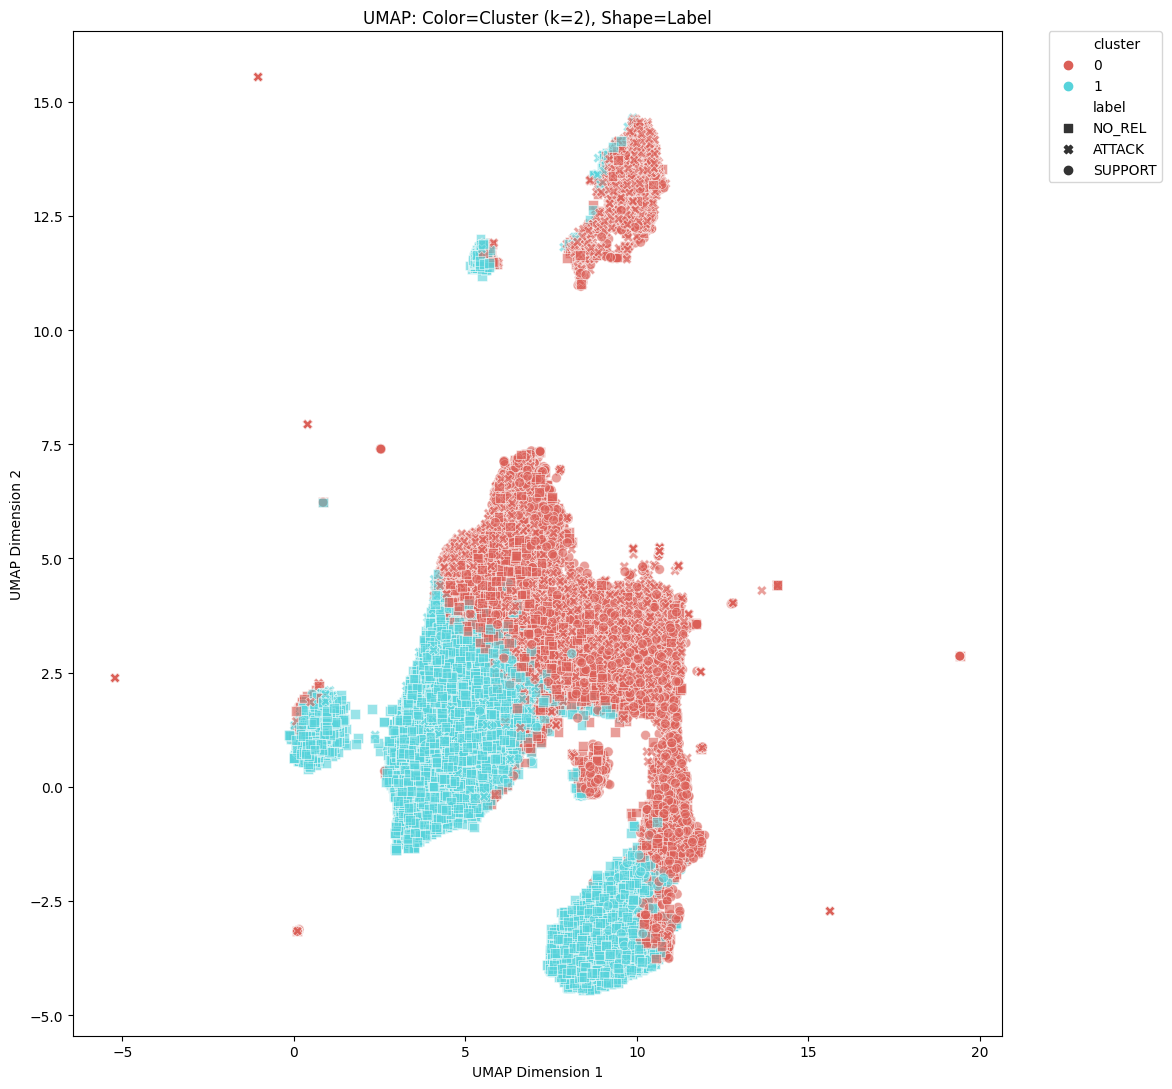

In [8]:
if df_aligned is not None and embeddings is not None and 'cluster' in df_aligned.columns:
    logger.info("Reducing dimensions with UMAP for visualization...")

    reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    embeddings_2d = reducer.fit_transform(embeddings)

    df_aligned['umap_1'] = embeddings_2d[:, 0]
    df_aligned['umap_2'] = embeddings_2d[:, 1]

    # --- Plot 1: Color by K-Means Cluster ---
    logger.info(f"Plotting by K-Means Cluster (k={n_clusters})...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',
        # Use a palette suitable for n_clusters
        palette=sns.color_palette('hls', n_clusters),
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title(f'K-Means (k={n_clusters}) Clusters visualized with UMAP')
    plt.show()

    # --- Plot 2: Color by Original Label ---
    logger.info("Plotting by Original Label...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='label',
        palette=sns.color_palette('hls', 3), # 3 original labels
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title('Original Labels (ATTACK, SUPPORT, NO_REL) visualized with UMAP')
    plt.show()

    # --- Plot 3 (NEW): Color by Cluster, Shape by Label ---
    logger.info(f"Plotting UMAP with Color=Cluster (k={n_clusters}), Shape=Original Label...")
    plt.figure(figsize=(14, 11))

    scatter = sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',      # Color by K-Means cluster
        style='label',      # Shape by original label
        palette=sns.color_palette('hls', n_clusters), # Use n_clusters colors
        markers={'ATTACK': 'X', 'SUPPORT': 'o', 'NO_REL': 's'}, # Assign markers
        data=df_aligned,
        alpha=0.6,
        s=50 # Point size
    )

    plt.title(f'UMAP: Color=Cluster (k={n_clusters}), Shape=Label')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

else:
    logger.error("Cannot create UMAP plots because data, embeddings, or cluster labels are missing.")

## Performing the KMeans for 3 Clusters

In [9]:
if df_aligned is not None and embeddings is not None:
    # --- SET YOUR DESIRED NUMBER OF CLUSTERS HERE ---
    n_clusters = 3
    # -------------------------------------------------

    logger.info(f"Running K-Means with n_clusters={n_clusters}...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Add cluster labels to the aligned DataFrame
    df_aligned['cluster'] = cluster_labels

    # Calculate Silhouette Score (only if more than 1 cluster)
    if n_clusters > 1:
        try:
            silhouette_avg = silhouette_score(embeddings, cluster_labels)
            logger.info(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.4f}")
        except Exception as e:
            logger.warning(f"Could not calculate silhouette score: {e}")
    else:
        logger.info("Silhouette score requires n_clusters > 1.")

else:
    logger.error("Cannot run K-Means because data or embeddings are not loaded.")

2025-10-29 09:12:15,603 - INFO - Running K-Means with n_clusters=3...
2025-10-29 09:13:14,303 - INFO - For n_clusters = 3, the average silhouette_score is : 0.1540


2025-10-29 09:13:14,311 - INFO - --- Cluster Composition Analysis ---


\nCross-tabulation (Original Label vs. Predicted Cluster):
cluster      0     1     2
label                     
ATTACK     585  4268  4907
NO_REL   15066  2922  2012
SUPPORT    599  9598   549


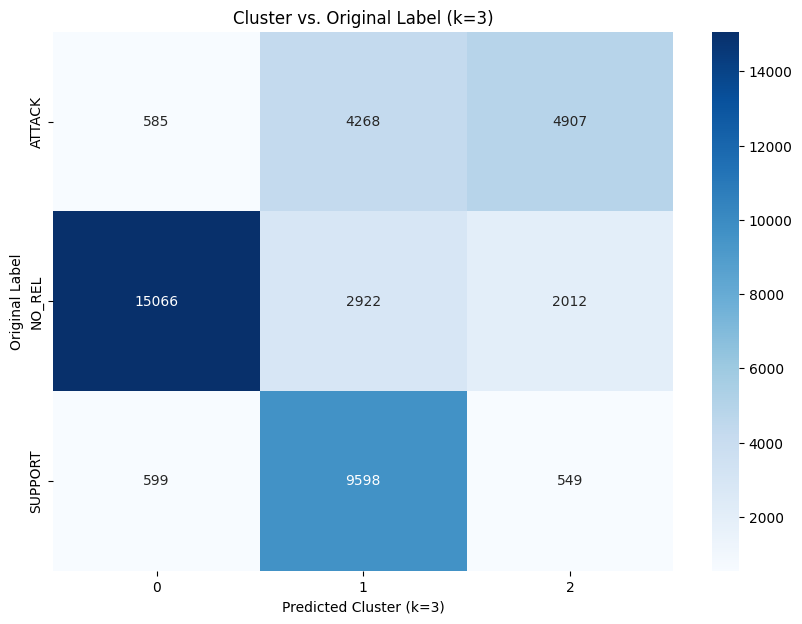

In [10]:
if df_aligned is not None:
    if 'cluster' in df_aligned.columns:
        logger.info("--- Cluster Composition Analysis ---")

        crosstab = pd.crosstab(df_aligned['label'], df_aligned['cluster'])
        print("\\nCross-tabulation (Original Label vs. Predicted Cluster):")
        print(crosstab)

        plt.figure(figsize=(10, 7)) # Adjusted size slightly
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
        # Use the n_clusters variable in the title and xlabel
        plt.title(f"Cluster vs. Original Label (k={n_clusters})")
        plt.xlabel(f"Predicted Cluster (k={n_clusters})")
        plt.ylabel("Original Label")
        plt.show()
    else:
        logger.error("K-Means clustering step did not complete. Cannot show composition.")
else:
    logger.error("Cannot analyze composition because data is not loaded.")

# ATTACK Recall: Precision: F1:
# Overall Accuracy: 29571/40506


In [11]:
if df_aligned is not None and 'cluster' in df_aligned.columns:
    pd.set_option('display.max_colwidth', 200)

    # Display samples for each cluster found
    unique_clusters = sorted(df_aligned['cluster'].unique())
    num_clusters_found = len(unique_clusters) # Get actual number found
    logger.info(f"Found {num_clusters_found} unique cluster labels: {unique_clusters}")


    for clus_id in unique_clusters:
        print("\\n" + "="*50)
        logger.info(f"Sample Points from Cluster {clus_id}")
        print("="*50)
        cluster_data = df_aligned[df_aligned['cluster'] == clus_id]
        sample_size = min(5, len(cluster_data)) # Sample up to 5

        if sample_size > 0:
           print(cluster_data[['sent1', 'sent2', 'label']].sample(sample_size, random_state=42))
        else:
           print(f"Cluster {clus_id} has no samples.")
else:
    logger.error("Cannot inspect samples because data or cluster labels are missing.")

2025-10-29 09:13:14,563 - INFO - Found 3 unique cluster labels: [0, 1, 2]
2025-10-29 09:13:14,564 - INFO - Sample Points from Cluster 0
2025-10-29 09:13:14,576 - INFO - Sample Points from Cluster 1
2025-10-29 09:13:14,587 - INFO - Sample Points from Cluster 2


\n==================================================
                                                                                                                                                                                                         sent1  \
2869                               Challenge in this appeal is to the order passed by a Division Bench of the Punjab and Haryana High Court which dismissed the appeal filed by the husband of the appellant .   
32768                                                               Under these circumstances , the conclusion reached by the disciplinary authority that he was wilfully absent from duty is well justified .   
29937                                                                                                      It is simply an idol set up by the Maharajah , apparently in his own house , and for what purpose ?   
2900   In these circumstances , therefore , we disbelieve this part of the case of the petitioner that he h

2025-10-29 09:13:14,607 - INFO - Reducing dimensions with UMAP for visualization...
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
2025-10-29 09:13:54,690 - INFO - Plotting by K-Means Cluster (k=3)...


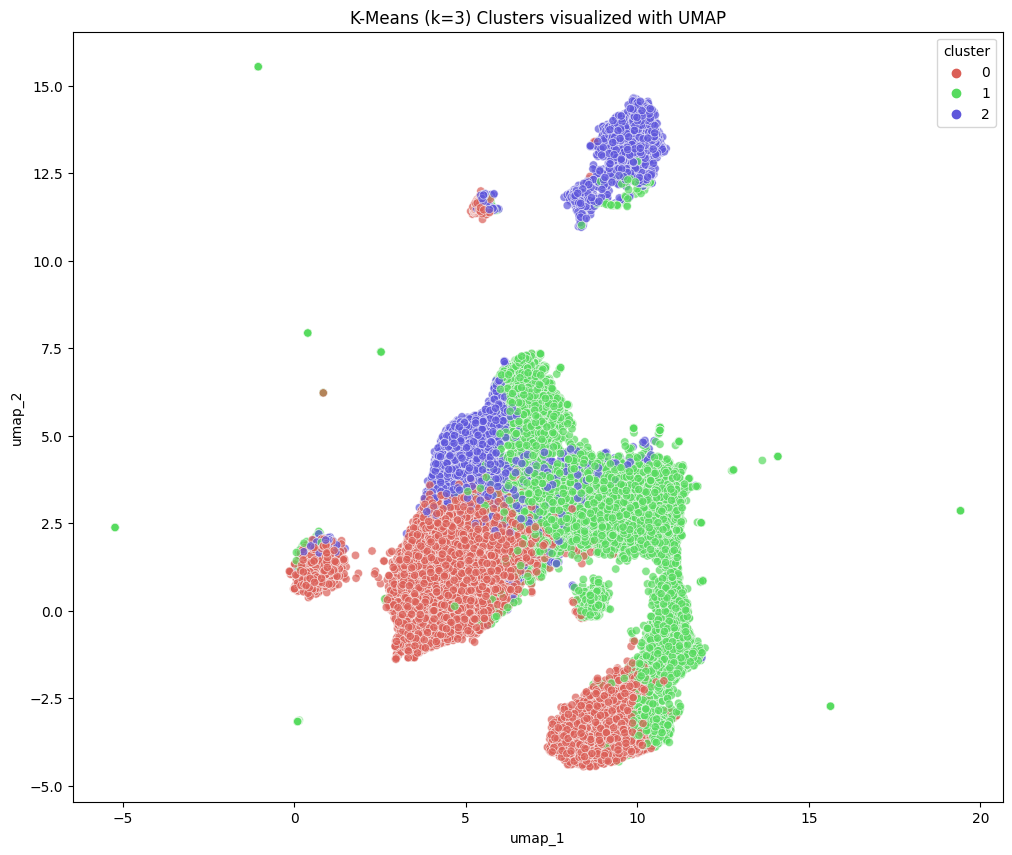

2025-10-29 09:13:56,114 - INFO - Plotting by Original Label...


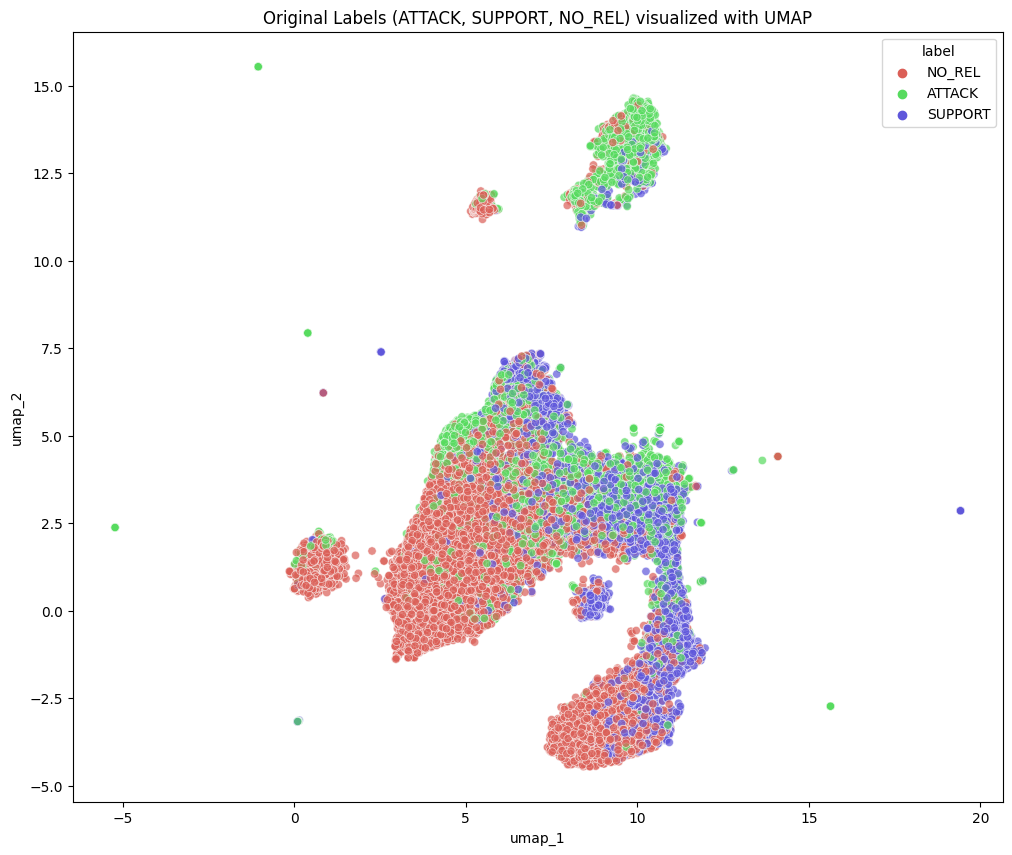

2025-10-29 09:13:57,523 - INFO - Plotting UMAP with Color=Cluster (k=3), Shape=Original Label...


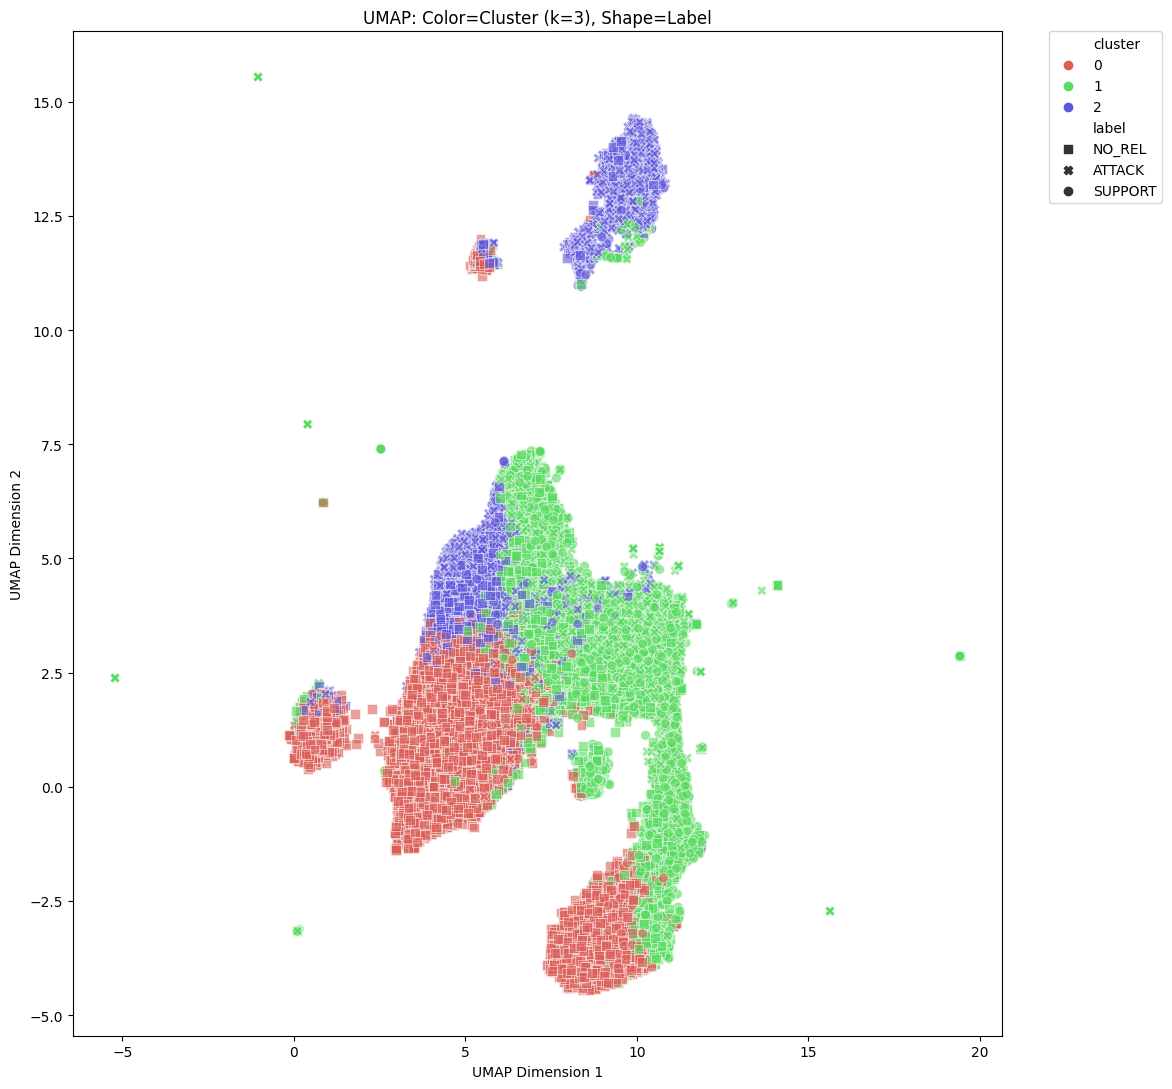

In [12]:
if df_aligned is not None and embeddings is not None and 'cluster' in df_aligned.columns:
    logger.info("Reducing dimensions with UMAP for visualization...")

    reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    embeddings_2d = reducer.fit_transform(embeddings)

    df_aligned['umap_1'] = embeddings_2d[:, 0]
    df_aligned['umap_2'] = embeddings_2d[:, 1]

    # --- Plot 1: Color by K-Means Cluster ---
    logger.info(f"Plotting by K-Means Cluster (k={n_clusters})...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',
        # Use a palette suitable for n_clusters
        palette=sns.color_palette('hls', n_clusters),
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title(f'K-Means (k={n_clusters}) Clusters visualized with UMAP')
    plt.show()

    # --- Plot 2: Color by Original Label ---
    logger.info("Plotting by Original Label...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='label',
        palette=sns.color_palette('hls', 3), # 3 original labels
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title('Original Labels (ATTACK, SUPPORT, NO_REL) visualized with UMAP')
    plt.show()

    # --- Plot 3 (NEW): Color by Cluster, Shape by Label ---
    logger.info(f"Plotting UMAP with Color=Cluster (k={n_clusters}), Shape=Original Label...")
    plt.figure(figsize=(14, 11))

    scatter = sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',      # Color by K-Means cluster
        style='label',      # Shape by original label
        palette=sns.color_palette('hls', n_clusters), # Use n_clusters colors
        markers={'ATTACK': 'X', 'SUPPORT': 'o', 'NO_REL': 's'}, # Assign markers
        data=df_aligned,
        alpha=0.6,
        s=50 # Point size
    )

    plt.title(f'UMAP: Color=Cluster (k={n_clusters}), Shape=Label')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

else:
    logger.error("Cannot create UMAP plots because data, embeddings, or cluster labels are missing.")

## Performing the KMeans for Optimal Clusters

In [13]:
if df_aligned is not None and embeddings is not None:
    
    n_clusters = 4
    # -------------------------------------------------

    logger.info(f"Running K-Means with n_clusters={n_clusters}...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(embeddings)

    # Add cluster labels to the aligned DataFrame
    df_aligned['cluster'] = cluster_labels

    # Calculate Silhouette Score (only if more than 1 cluster)
    if n_clusters > 1:
        try:
            silhouette_avg = silhouette_score(embeddings, cluster_labels)
            logger.info(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg:.4f}")
        except Exception as e:
            logger.warning(f"Could not calculate silhouette score: {e}")
    else:
        logger.info("Silhouette score requires n_clusters > 1.")

else:
    logger.error("Cannot run K-Means because data or embeddings are not loaded.")

2025-10-29 09:13:58,779 - INFO - Running K-Means with n_clusters=4...
2025-10-29 09:14:57,803 - INFO - For n_clusters = 4, the average silhouette_score is : 0.1336


2025-10-29 09:14:57,811 - INFO - --- Cluster Composition Analysis ---


\nCross-tabulation (Original Label vs. Predicted Cluster):
cluster      0     1     2     3
label                           
ATTACK     628  4540   112  4480
NO_REL   11931  1440  4392  2237
SUPPORT    189   433  1745  8379


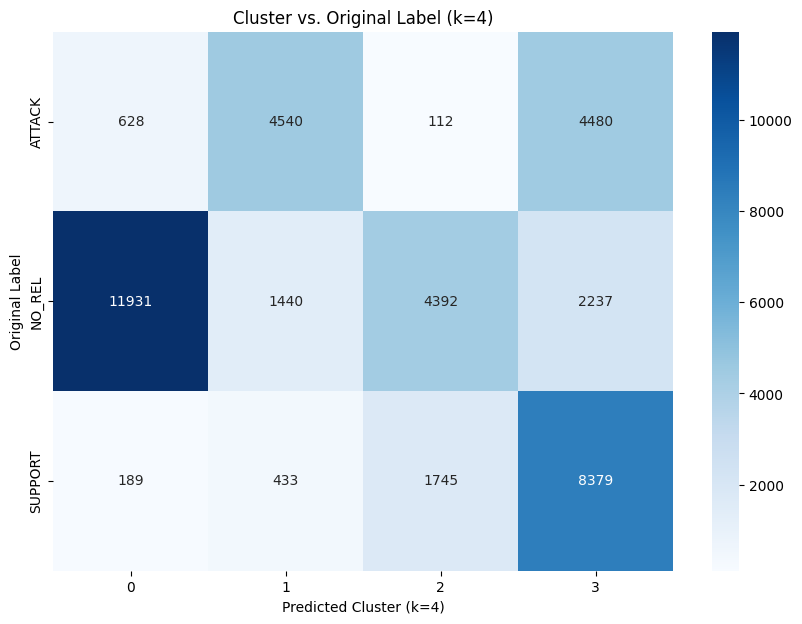

In [14]:
if df_aligned is not None:
    if 'cluster' in df_aligned.columns:
        logger.info("--- Cluster Composition Analysis ---")

        crosstab = pd.crosstab(df_aligned['label'], df_aligned['cluster'])
        print("\\nCross-tabulation (Original Label vs. Predicted Cluster):")
        print(crosstab)

        plt.figure(figsize=(10, 7)) # Adjusted size slightly
        sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
        # Use the n_clusters variable in the title and xlabel
        plt.title(f"Cluster vs. Original Label (k={n_clusters})")
        plt.xlabel(f"Predicted Cluster (k={n_clusters})")
        plt.ylabel("Original Label")
        plt.show()
    else:
        logger.error("K-Means clustering step did not complete. Cannot show composition.")
else:
    logger.error("Cannot analyze composition because data is not loaded.")




In [15]:
if df_aligned is not None and 'cluster' in df_aligned.columns:
    pd.set_option('display.max_colwidth', 200)

    # Display samples for each cluster found
    unique_clusters = sorted(df_aligned['cluster'].unique())
    num_clusters_found = len(unique_clusters) # Get actual number found
    logger.info(f"Found {num_clusters_found} unique cluster labels: {unique_clusters}")


    for clus_id in unique_clusters:
        print("\\n" + "="*50)
        logger.info(f"Sample Points from Cluster {clus_id}")
        print("="*50)
        cluster_data = df_aligned[df_aligned['cluster'] == clus_id]
        sample_size = min(5, len(cluster_data)) # Sample up to 5

        if sample_size > 0:
           print(cluster_data[['sent1', 'sent2', 'label']].sample(sample_size, random_state=42))
        else:
           print(f"Cluster {clus_id} has no samples.")
else:
    logger.error("Cannot inspect samples because data or cluster labels are missing.")

2025-10-29 09:14:58,050 - INFO - Found 4 unique cluster labels: [0, 1, 2, 3]
2025-10-29 09:14:58,051 - INFO - Sample Points from Cluster 0
2025-10-29 09:14:58,061 - INFO - Sample Points from Cluster 1
2025-10-29 09:14:58,069 - INFO - Sample Points from Cluster 2
2025-10-29 09:14:58,076 - INFO - Sample Points from Cluster 3


\n==================================================
                                                                                                                                                                                                         sent1  \
28346  In the preceding paragraph of its judgment the High Court has referred to the evidence of eye witnesses and curiously observed that assuming if their evidence is acceptable it would only show that...   
14814  If that word has a limited meaning , which is the case of the petitioner , it is contended that that power of amendment could not be enlarged by the use of the words " amend by way of addition , v...   
24728  Respondents submitted that they had made a specific averment in their writ petition in regard to the lack of circulation of the two newspapers as follows : " The Notification was alleged to have b...   
20431  Advant and others.(1 ) Counsel for the petitioner contended that every order made by a public author

2025-10-29 09:14:58,096 - INFO - Reducing dimensions with UMAP for visualization...
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.11/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
2025-10-29 09:15:38,767 - INFO - Plotting by K-Means Cluster (k=4)...


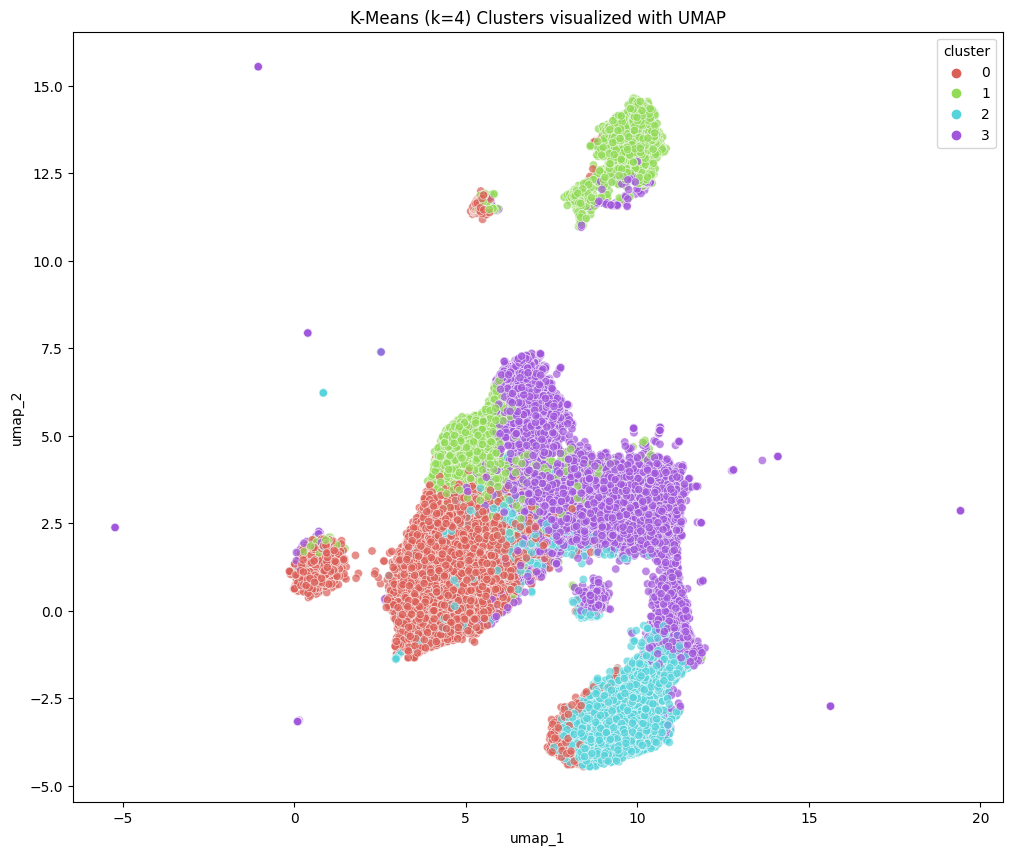

2025-10-29 09:15:40,208 - INFO - Plotting by Original Label...


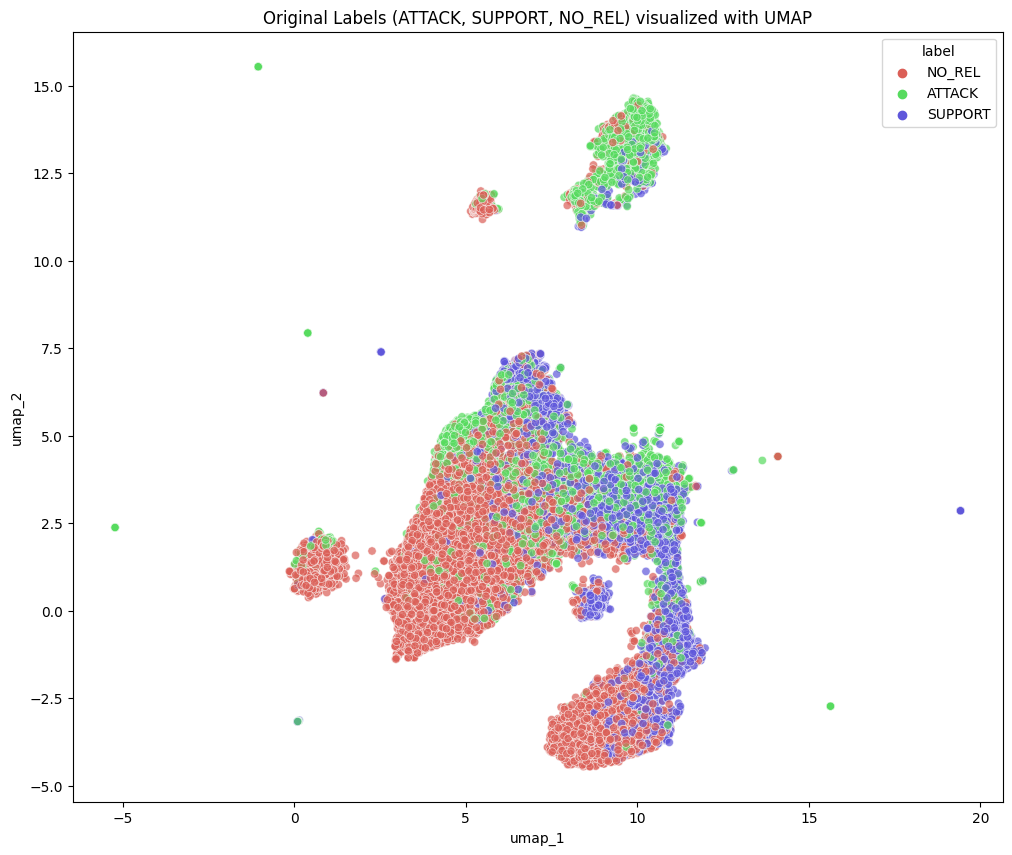

2025-10-29 09:15:41,626 - INFO - Plotting UMAP with Color=Cluster (k=4), Shape=Original Label...


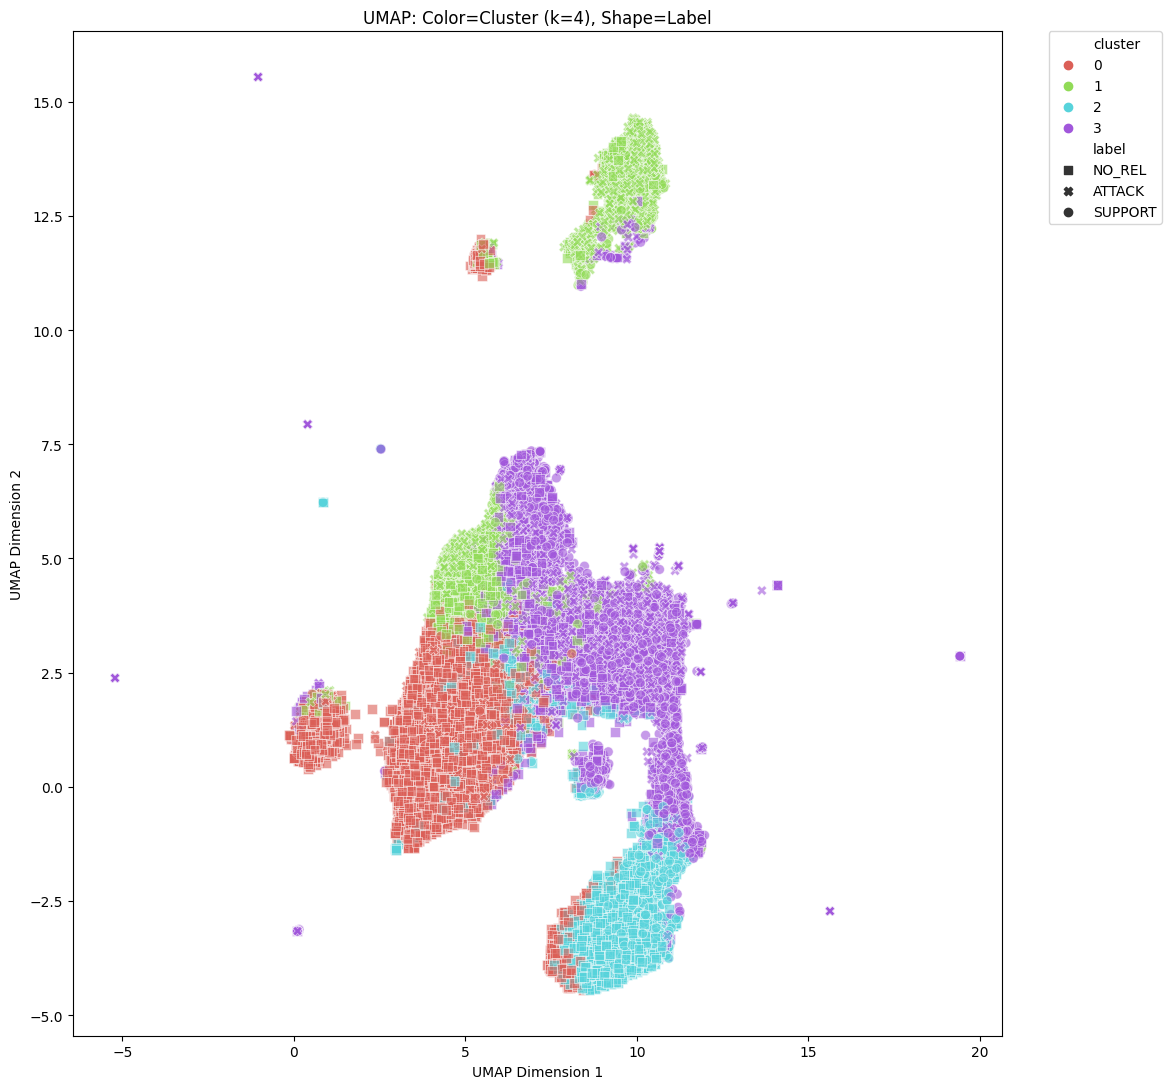

In [16]:
if df_aligned is not None and embeddings is not None and 'cluster' in df_aligned.columns:
    logger.info("Reducing dimensions with UMAP for visualization...")

    reducer = umap.UMAP(n_components=2, random_state=42, metric='cosine')
    embeddings_2d = reducer.fit_transform(embeddings)

    df_aligned['umap_1'] = embeddings_2d[:, 0]
    df_aligned['umap_2'] = embeddings_2d[:, 1]

    # --- Plot 1: Color by K-Means Cluster ---
    logger.info(f"Plotting by K-Means Cluster (k={n_clusters})...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',
        # Use a palette suitable for n_clusters
        palette=sns.color_palette('hls', n_clusters),
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title(f'K-Means (k={n_clusters}) Clusters visualized with UMAP')
    plt.show()

    # --- Plot 2: Color by Original Label ---
    logger.info("Plotting by Original Label...")
    plt.figure(figsize=(12, 10))
    sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='label',
        palette=sns.color_palette('hls', 3), # 3 original labels
        data=df_aligned,
        legend='full',
        alpha=0.7
    )
    plt.title('Original Labels (ATTACK, SUPPORT, NO_REL) visualized with UMAP')
    plt.show()

    # --- Plot 3 (NEW): Color by Cluster, Shape by Label ---
    logger.info(f"Plotting UMAP with Color=Cluster (k={n_clusters}), Shape=Original Label...")
    plt.figure(figsize=(14, 11))

    scatter = sns.scatterplot(
        x='umap_1', y='umap_2',
        hue='cluster',      # Color by K-Means cluster
        style='label',      # Shape by original label
        palette=sns.color_palette('hls', n_clusters), # Use n_clusters colors
        markers={'ATTACK': 'X', 'SUPPORT': 'o', 'NO_REL': 's'}, # Assign markers
        data=df_aligned,
        alpha=0.6,
        s=50 # Point size
    )

    plt.title(f'UMAP: Color=Cluster (k={n_clusters}), Shape=Label')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

else:
    logger.error("Cannot create UMAP plots because data, embeddings, or cluster labels are missing.")